# Aprendizaje Automático con Python

### 14 de Mayo del 2026
### TI3002C
### ITESM
### oscarnava@tec.mx


## Entrenando Modelos de Árboles de Decisión y Random Forest en Python

En este notebook, exploraremos cómo entrenar y evaluar modelos de **Árboles de Decisión** y **Random Forest** utilizando Python y la biblioteca `scikit-learn`. Estos algoritmos son muy populares y poderosos para tareas de clasificación. Trabajaremos con un conjunto de datos sintético proporcionado por Liverpool, el cual contiene información sobre marcas, ventas y otras métricas.

El objetivo principal es predecir si una marca **"Renovó"** su registro (nuestra variable objetivo) basándonos en las demás características del dataset.

In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Configurar el estilo de los gráficos
sns.set_style('whitegrid')

### Carga y Exploración de Datos
Comenzaremos cargando una muestra del dataset provisto y explorando sus características básicas para entender con qué estamos trabajando.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = '/content/drive/MyDrive/Synthetic data/'

df_ventas = pd.read_excel(BASE_PATH + 'procesamiento_final.xlsx', sheet_name='Ventas')
df_marcas = pd.read_excel(BASE_PATH + 'procesamiento_final.xlsx', sheet_name='Marcas')

print(f'Ventas : {df_ventas.shape}')
print(f'Marcas : {df_marcas.shape}')

Ventas : (2764, 17)
Marcas : (14488, 24)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   DENOMINACIÓN                        2764 non-null   object 
 1   Descripción                         2764 non-null   object 
 2   Total Sales                         2764 non-null   float64
 3   Revenue                             2764 non-null   float64
 4   Antigüedad de la Marca              2764 non-null   int64  
 5   Número de Leads en Web              2764 non-null   float64
 6   Calificación Promedio de Productos  2764 non-null   float64
 7   Número de Devoluciones              2764 non-null   float64
 8   Renovó                              2764 non-null   object 
 9   Participación de Mercado (%)        2764 non-null   float64
 10  Avg Market Share                    2764 non-null   float64
 11  Crecimiento Total Sales             2764 no

join

In [ ]:
df_ventas.columns = df_ventas.columns.str.strip()
df_marcas.columns = df_marcas.columns.str.strip()

df_ventas['DENOMINACIÓN'] = df_ventas['DENOMINACIÓN'].astype(str).str.strip()
df_marcas['DENOMINACIÓN'] = df_marcas['DENOMINACIÓN'].astype(str).str.strip()

cols_marcas = [
    'DENOMINACIÓN',
    'Antiguedadde Marca',
    'Tiempo restante de renovación',
    'Estatus estrégico de Marca',
    'Prioridad de Negocio',
    'ReviewScore',
    'Review'
]

marcas_agg = (
    df_marcas[cols_marcas]
    .dropna(subset=['DENOMINACIÓN'])
    .groupby('DENOMINACIÓN')
    .agg({
        'Antiguedadde Marca': 'mean',
        'Tiempo restante de renovación': 'mean',
        'Estatus estrégico de Marca': 'first',
        'Prioridad de Negocio': 'first',
        'ReviewScore': 'mean',
        'Review': 'first'
    })
    .reset_index()
)

df = df_ventas.merge(marcas_agg, on='DENOMINACIÓN', how='left')

print(f'Dataset combinado: {df.shape}')
df.head(3)

Dataset combinado: (2764, 23)


,DENOMINACIÓN,Descripción,Total Sales,Revenue,Antigüedad de la Marca,Número de Leads en Web,Calificación Promedio de Productos,Número de Devoluciones,Renovó,Participación de Mercado (%),...,Tasa de conversión,Tasa de devolución,Revenue Por Lead,Clasificación de Marca,Antiguedadde Marca,Tiempo restante de renovación,Estatus estrégico de Marca,Prioridad de Negocio,ReviewScore,Review
0,#OCTUBREROSA CUIDATE,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",335.125,73405.166826,7,52.250000,3.254327,56.750000,si,0.001140,...,6.413876,0.169340,1404.883576,Baja,7.0,-3.0,Activa,Alta,3.66,Media
1,#OCTUBREROSA CUIDATE,PUBLICIDAD; GESTION DE NEGOCIOS COMERCIALES; A...,321.875,92774.969078,7,63.000000,3.198713,51.750000,si,0.001505,...,5.109127,0.160777,1472.618557,Baja,7.0,-3.0,Activa,Alta,3.66,Media
2,#ZONA D,"PRENDAS DE VESTIR, CALZADO, ARTICULOS DE SOMBR...",172.000,72234.359445,11,29.272727,2.327540,30.272727,no,0.001579,...,5.875776,0.176004,2467.633397,Baja,4.0,84.0,NO ESTRATÉGICA,SI,3.85,Media


### Preprocesamiento de Datos
Antes de entrenar los modelos necesitamos:
1. Seleccionar las características principales (*features*) y lo que queremos predecir (*target*).
2. Convertir los valores de texto de la columna a predecir (`si`/`no`) en valores binarios (`1`/`0`).
3. Dividir el conjunto total en un grupo de **entrenamiento** (para que los modelos aprendan) y otro grupo de **prueba** (para medir qué tan bien aprendieron).

In [ ]:
# Separar X y y
features = [
    'Tasa de conversión',
    'Clasificación de Marca',
    'Antigüedad de la Marca',
    'Crecimiento Total Sales',
    'ReviewScore',
    'Tasa de devolución'
]

target = 'Renovó'

X = df[features]
y = df[target].map({'si': 1, 'no': 0})

# Convertir columnas de texto a columnas numéricas
X = pd.get_dummies(X, drop_first=True)

# Dividir entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

### Modelo 1: Árbol de Decisión
Un árbol de decisión es un modelo predictivo que toma decisiones basándose en una serie de preguntas condicionales sobre los datos. Es fácil de entender e interpretar, pero puede sufrir de *overfitting* (sobreajuste), lo que significa que memoriza los datos de entrenamiento pero se equivoca con datos nuevos.

In [ ]:
# Inicializar y entrenar el modelo de Árbol de Decisión
decision_tree_model = DecisionTreeClassifier(random_state=3002)
decision_tree_model.fit(X_train, y_train)

# Realizar predicciones usando los datos reservados para prueba
y_pred_dt = decision_tree_model.predict(X_test)

#### Evaluación del Árbol de Decisión
Generamos un reporte con métricas clave y una Matriz de Confusión para visualizar en qué clases acierta y en cuáles se equivoca.

--- Métricas de Árbol de Decisión ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       229
           1       0.99      0.99      0.99       601

    accuracy                           0.98       830
   macro avg       0.98      0.98      0.98       830
weighted avg       0.98      0.98      0.98       830

Especificidad: 0.98


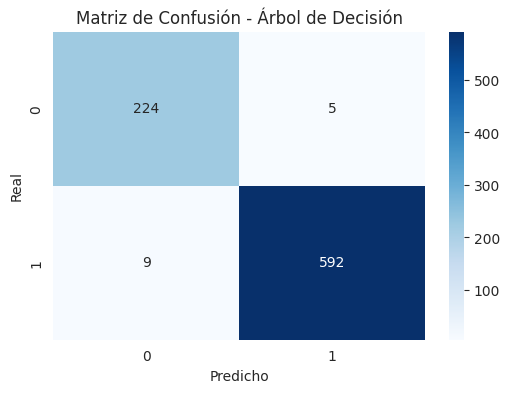

In [ ]:
print("--- Métricas de Árbol de Decisión ---")
print(classification_report(y_test, y_pred_dt))

# Cálculo de Especificidad
cm_dt = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm_dt.ravel()
specificity_dt = tn / (tn + fp)
print(f"Especificidad: {specificity_dt:.2f}")

# Creación de la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### Visualización Avanzada del Árbol de Decisión con Graphviz

Para una visualización aún más detallada y personalizable del árbol de decisión, podemos utilizar la librería `graphviz`. Esto nos permite generar un gráfico interactivo o de mayor calidad que `plot_tree` de `scikit-learn`.

In [ ]:
# Instalar graphviz si no está instalado
!pip install graphviz

import graphviz
from sklearn.tree import export_graphviz

# Exportar el árbol a un archivo DOT
dot_data = export_graphviz(decision_tree_model,
                           feature_names=features,
                           class_names=['No Renovó', 'Renovó'],
                           filled=True, rounded=True,
                           special_characters=True,
                           proportion=True,
                           out_file=None)

# Renderizar el gráfico
graph = graphviz.Source(dot_data)

# Guardar y mostrar el gráfico
graph.render("decision_tree_graphviz", format='png', view=True)
print("Gráfico del árbol de decisión generado y guardado como 'decision_tree_graphviz.png'. Se abrirá automáticamente.")


Gráfico del árbol de decisión generado y guardado como 'decision_tree_graphviz.png'. Se abrirá automáticamente.


In [ ]:
# Para mostrar el gráfico directamente en el notebook (opcional si ya se abrió con view=True)
graph

NameError: name 'graph' is not defined

El archivo `decision_tree_graphviz.png` ha sido generado y debería abrirse automáticamente en su navegador o visor de imágenes predeterminado. También puedes ver el renderizado del gráfico directamente aquí.

### Modelo 2: Random Forest (Bosque Aleatorio)
El modelo de *Random Forest* construye una multitud de árboles de decisión en la fase de entrenamiento y nos entrega el promedio o mayoría de sus decisiones. Esto ayuda a prevenir el sobreajuste que veíamos en los árboles de decisión individuales.

In [ ]:
# Inicializar y entrenar el modelo Random Forest
# 'n_estimators' define la cantidad de árboles de decisión que crearán el "bosque"
rf_model = RandomForestClassifier(random_state=3002, n_estimators=100)
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

#### Evaluación del Random Forest
Comparamos los resultados para ver si construir múltiples árboles (Random Forest) nos ofreció un mejor desempeño.

--- Métricas de Random Forest ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       229
           1       0.99      0.98      0.98       601

    accuracy                           0.98       830
   macro avg       0.97      0.98      0.97       830
weighted avg       0.98      0.98      0.98       830

Especificidad: 0.98


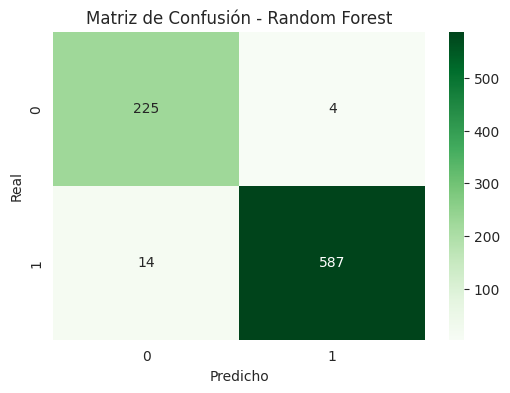

In [ ]:
print("--- Métricas de Random Forest ---")
print(classification_report(y_test, y_pred_rf))

# Cálculo de Especificidad
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
specificity_rf = tn / (tn + fp)
print(f"Especificidad: {specificity_rf:.2f}")

# Matriz de Confusión para Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### Modelo 3: Gradient Boosting Tree (GBT)
El *Gradient Boosting* es otra técnica de ensamble que, a diferencia del Random Forest, entrena árboles de forma secuencial. Cada nuevo árbol intenta corregir los errores residuales del modelo acumulado hasta el momento, lo que suele ofrecer una gran precisión.

--- Métricas de Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       228
           1       0.99      0.96      0.97       602

    accuracy                           0.96       830
   macro avg       0.95      0.96      0.96       830
weighted avg       0.97      0.96      0.96       830

Especificidad: 0.96


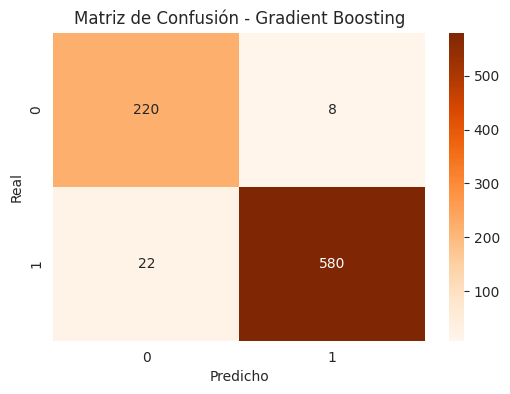

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Inicializar y entrenar el modelo Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=3002, n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_gb = gb_model.predict(X_test)

# Evaluación del Gradient Boosting
print("--- Métricas de Gradient Boosting ---")
print(classification_report(y_test, y_pred_gb))

# Cálculo de Especificidad
cm_gb = confusion_matrix(y_test, y_pred_gb)
tn, fp, fn, tp = cm_gb.ravel()
specificity_gb = tn / (tn + fp)
print(f"Especificidad: {specificity_gb:.2f}")

# Matriz de Confusión para Gradient Boosting
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión - Gradient Boosting')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### Persistencia del Modelo
Para evitar reentrenar el modelo cada vez que necesitemos usarlo, podemos guardarlo en un archivo utilizando la biblioteca `joblib`. Esto permite exportar el modelo entrenado y cargarlo posteriormente en este o en otros entornos.

In [ ]:
y_pred = gb_model.predict(X.iloc[0:3])

In [ ]:
import joblib

filename = 'gradientboostingfinal.joblib'

joblib.dump(gb_model, filename)

print(f"Modelo '{filename}' guardado exitosamente.")

Modelo 'gradientboostingfinal.joblib' guardado exitosamente.


##probar el modelo

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': gb_model.feature_importances_
})

importancias = importancias.sort_values(
    by='Importancia',
    ascending=False
)

importancias

,Variable,Importancia
0,Tasa de conversión,0.445200
1,Antigüedad de la Marca,0.435359
2,Crecimiento Total Sales,0.091541
4,Tasa de devolución,0.019842
3,ReviewScore,0.003875
5,Clasificación de Marca_Media,0.002450
6,Clasificación de Marca_Top,0.001733


/tmp/ipykernel_5928/3303194047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


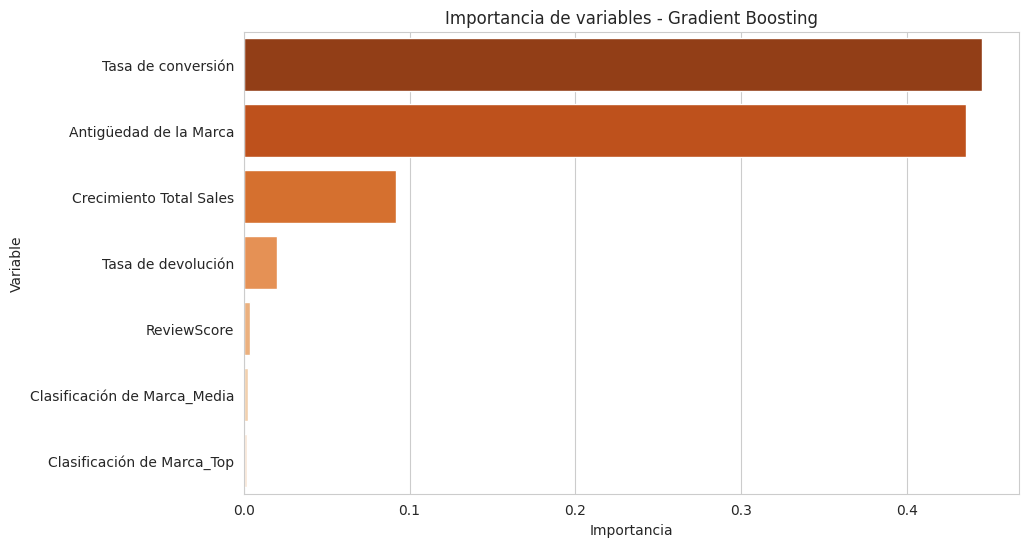

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancias,
    x='Importancia',
    y='Variable',
    palette='Oranges_r'
)

plt.title('Importancia de variables - Gradient Boosting')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

##one to one

In [ ]:
# 1 a 1

registro_marca = {'Antigüedad de la Marca': 37.0, 'Tasa de conversión': 8941.078577753173, 'Antigüedad de la Marca': 7.0, 'ReviewScore': 12.0, 'Clasificación de Marca': Alta,'Crecimiento Total Sales':0.5}
predicción = loaded_model.predict(np.array(list(registro_marca.values())).reshape(1, -1))
print(registro_marca)
print(predicción)


##batch

In [ ]:
# Batch Data

batch_data_df = pd.read_excel("batch_data.xlsx")
batch_data_df.drop(columns=["Antigüedad de la Marca","Tasa de conversión", "Antigüedad de la Marca", "ReviewScore", "Clasificación de Marca","Crecimiento Total Sales"],inplace=True)
batch_data_df.head()
loaded_model.predict(batch_data_df)